# 03 — Avaliação do método de imputação

## Protocolo (reprodutível)

1. **Partição de teste** (2014-07 → 2014-12), janelas **sem sobreposição**,
   nunca vista no treino nem na escolha do modelo;
2. **Máscaras determinísticas** (semente fixa = 123): removemos artificialmente
   pontos cuja verdade conhecemos e medimos o erro de reconstrução —
   6 cenários: falhas **pontuais** e em **blocos** × 10 %, 25 % e 50 % de dados faltantes;
3. **Métricas apenas nas posições mascaradas**: MAE e RMSE (escala normalizada
   e kW) e MRE (escala original);
4. **Baselines clássicos** ([src/baselines.py](src/baselines.py)): interpolação
   linear, repetição do último valor (ffill) e média da janela.

O protocolo inteiro está em [src/avaliacao.py](src/avaliacao.py) — a última seção
mostra como reaproveitá-lo em **outros datasets**.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA, SERIES, TINTA_2, DESTAQUE_MASCARA
from src.treino import carregar_modelo
from src.mascaramento import mascaras_avaliacao, trechos_mascarados
from src.avaliacao import avaliar_metodos, imputar_bert_lotes
from src.baselines import BASELINES

aplicar_estilo()

device = "cuda" if torch.cuda.is_available() else "cpu"
arrays, stats, cfg_dados = dados.carregar_processado("dados_processados")
modelo = carregar_modelo("resultados/melhor_modelo.pt", device)

j_teste, id_teste = arrays["teste"], arrays["id_teste"]
desvios = stats["desvio"].to_numpy()[id_teste].astype("float32")
medias = stats["media"].to_numpy()[id_teste].astype("float32")
print(f"janelas de teste: {j_teste.shape}  |  device: {device}")

janelas de teste: (2600, 168)  |  device: cuda


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Avaliação nos 6 cenários

In [2]:
%%time
cenarios = [
    (f"{tipo} {int(razao*100)}%", tipo, razao)
    for tipo in ("pontual", "bloco")
    for razao in (0.10, 0.25, 0.50)
]
resultados = avaliar_metodos(
    j_teste, modelo, device, cenarios,
    semente=123, desvios=desvios, medias=medias,
)
resultados.round(4)

CPU times: total: 35.3 s
Wall time: 22.2 s


,cenário,método,MAE,RMSE,MAE_kW,RMSE_kW,MRE
0,pontual 10%,BERT (proposto),0.1315,0.2067,14.9422,47.6717,0.0446
1,pontual 10%,média da janela,0.7789,0.9239,106.8868,308.9570,0.3194
2,pontual 10%,último valor (ffill),0.2929,0.4686,35.6964,145.3564,0.1067
3,pontual 10%,interpolação linear,0.1841,0.2884,21.5006,78.1609,0.0642
4,pontual 25%,BERT (proposto),0.1373,0.2114,15.3225,47.0040,0.0459
5,pontual 25%,média da janela,0.7808,0.9250,106.7318,306.4373,0.3195
6,pontual 25%,último valor (ffill),0.3313,0.5311,40.6077,169.0464,0.1216
7,pontual 25%,interpolação linear,0.2056,0.3170,24.4568,90.7781,0.0732
8,pontual 50%,BERT (proposto),0.1558,0.2384,17.1186,53.0242,0.0514
9,pontual 50%,média da janela,0.7819,0.9274,106.7003,304.3590,0.3203


In [3]:
tabela_mae = resultados.pivot(index="cenário", columns="método", values="MAE")
ordem = ["BERT (proposto)", "interpolação linear", "último valor (ffill)", "média da janela"]
print("MAE (escala normalizada) — menor é melhor")
tabela_mae[ordem].round(4)

MAE (escala normalizada) — menor é melhor


método,BERT (proposto),interpolação linear,último valor (ffill),média da janela
cenário,,,,
bloco 10%,0.1727,0.5660,0.7728,0.7884
bloco 25%,0.1756,0.5756,0.7809,0.7987
bloco 50%,0.1877,0.5758,0.7864,0.7972
pontual 10%,0.1315,0.1841,0.2929,0.7789
pontual 25%,0.1373,0.2056,0.3313,0.7808
pontual 50%,0.1558,0.2697,0.4349,0.7819


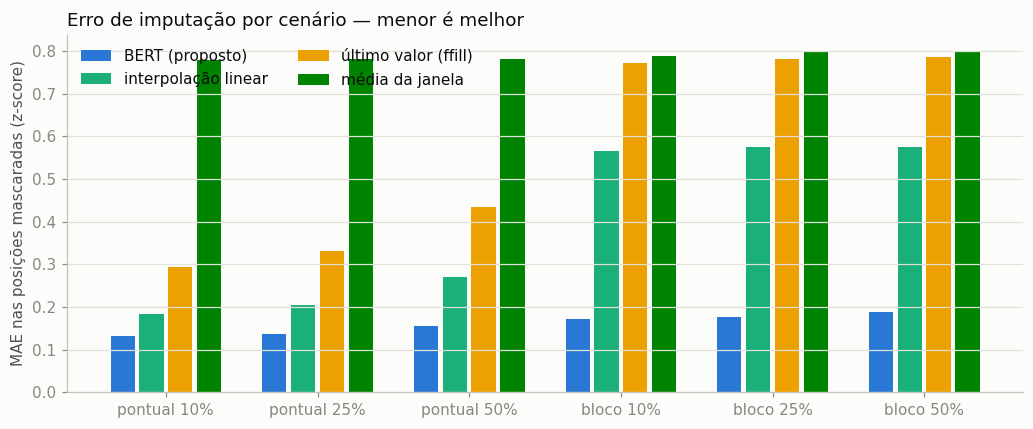

In [4]:
cores = dict(zip(ordem, SERIES[:4]))
nomes_cen = [c[0] for c in cenarios]
x = np.arange(len(nomes_cen))
larg = 0.19

fig, eixo = plt.subplots(figsize=(9.5, 4))
for k, met in enumerate(ordem):
    v = tabela_mae.loc[nomes_cen, met].to_numpy()
    eixo.bar(x + (k - 1.5) * larg, v, width=larg - 0.03, color=cores[met], label=met)
eixo.set_xticks(x)
eixo.set_xticklabels(nomes_cen)
eixo.set_ylabel("MAE nas posições mascaradas (z-score)")
eixo.set_title("Erro de imputação por cenário — menor é melhor", loc="left")
eixo.legend(ncols=2, loc="upper left")
eixo.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Exemplo qualitativo

Uma janela de teste com 25 % de falhas em bloco: verdade (linha escura), trechos
escondidos (faixas cinzas) e as imputações do BERT e da interpolação linear.
A interpolação liga os extremos do buraco com uma reta; o BERT reconstrói o
**formato** do ciclo diário dentro do buraco, porque aprendeu a sazonalidade.

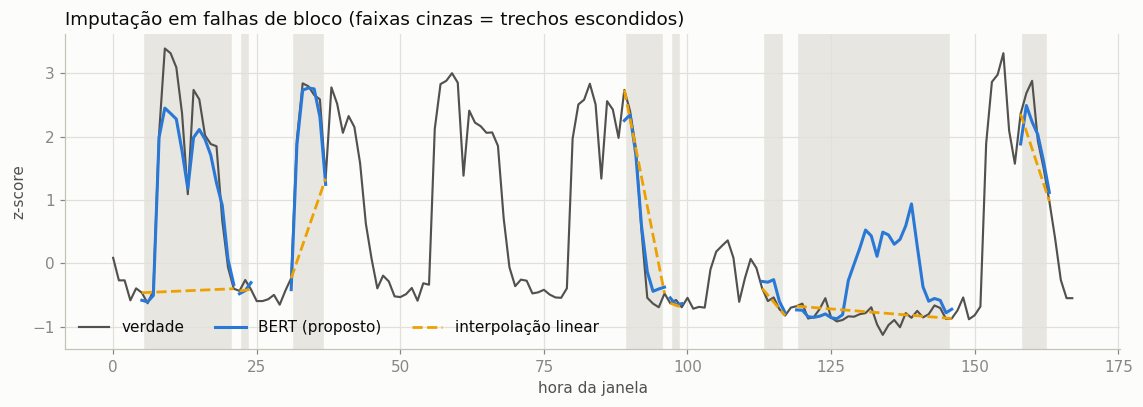

In [5]:
idx_exemplo = 17
x = torch.from_numpy(j_teste[idx_exemplo : idx_exemplo + 1])
masc = mascaras_avaliacao(1, x.shape[1], "bloco", 0.25, semente=7)
imput_bert = imputar_bert_lotes(modelo, x, masc, device)[0].numpy()
imput_lin = BASELINES["interpolação linear"](x, masc)[0].numpy()

m = masc[0].numpy()
t = np.arange(x.shape[1])
fig, eixo = plt.subplots(figsize=(10.5, 3.8))
for ini, fim in trechos_mascarados(m):
    eixo.axvspan(ini - 0.5, fim - 0.5, color=DESTAQUE_MASCARA, zorder=0)
eixo.plot(t, x[0], color=TINTA_2, linewidth=1.4, label="verdade")
for ini, fim in trechos_mascarados(m):
    tr = slice(max(ini - 1, 0), min(fim + 1, len(t)))
    eixo.plot(t[tr], imput_bert[tr], color=PALETA["azul"], linewidth=2.0,
              label="BERT (proposto)" if ini == trechos_mascarados(m)[0][0] else None)
    eixo.plot(t[tr], imput_lin[tr], color=PALETA["amarelo"], linewidth=1.8, linestyle="--",
              label="interpolação linear" if ini == trechos_mascarados(m)[0][0] else None)
eixo.set_xlabel("hora da janela")
eixo.set_ylabel("z-score")
eixo.set_title("Imputação em falhas de bloco (faixas cinzas = trechos escondidos)", loc="left")
eixo.legend(ncols=3)
fig.tight_layout()
plt.show()

## Salvar resultados

In [6]:
Path("resultados").mkdir(exist_ok=True)
resultados.to_csv("resultados/metricas_teste.csv", index=False)
resultados.to_json("resultados/metricas_teste.json", orient="records", indent=2)
print("salvo em resultados/metricas_teste.{csv,json}")

salvo em resultados/metricas_teste.{csv,json}


## Como aplicar o método a OUTRO dataset

O modelo é univariado e aceita qualquer comprimento de janela, então basta
repetir o pipeline de dados no novo conjunto e chamar o mesmo protocolo.
Modelo de código (troque o caminho/colunas do seu dataset):

```python
# 1. carregar qualquer CSV com índice datetime e uma coluna por série
df_novo = pd.read_csv("outro_dataset.csv", index_col=0, parse_dates=True)
df_novo = df_novo.resample("1h").mean()          # mesma resolução do pré-treino

# 2. mesmo pipeline: divisão temporal + z-score (stats do treino do PRÓPRIO dataset)
tr, va, te = dados.dividir_temporal(df_novo, "<fim_treino>", "<fim_val>")
stats_novo = dados.ajustar_normalizador(tr)
te_n = dados.normalizar(te, stats_novo)

# 3. janelar e avaliar com o MESMO protocolo (mesma semente -> mesmas máscaras)
j, ids = dados.janelar(te_n, comprimento=168, passo=168)
res = avaliar_metodos(
    j, modelo, device, cenarios, semente=123,
    desvios=stats_novo["desvio"].to_numpy()[ids].astype("float32"),
    medias=stats_novo["media"].to_numpy()[ids].astype("float32"),
)
```

Duas formas de uso no novo dataset:

- **Zero-shot:** avaliar o modelo pré-treinado direto (mede a generalização do
  pré-treino auto-supervisionado);
- **Fine-tuning:** continuar o treino (`src.treino.treinar`) por poucas épocas
  nas janelas de treino do novo dataset antes de avaliar.

## Referências

- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers
  for Language Understanding*. NAACL.
- Zerveas et al. (2021). *A Transformer-based Framework for Multivariate Time
  Series Representation Learning*. KDD.
- Du, Côté & Liu (2023). *SAITS: Self-Attention-based Imputation for Time
  Series*. Expert Systems with Applications.
- Trindade (2015). *ElectricityLoadDiagrams20112014*. UCI ML Repository.